In [1]:
!pip install sentence-transformers seaborn

In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
sentences = [

# Cricket
"The batsman scored a century in the final match.",
"The bowler delivered a perfect yorker to dismiss the player.",
"The team celebrated after winning the cricket world cup.",

# Cooking
"I added fresh garlic and butter to the pasta sauce.",
"The chef baked a chocolate cake in the oven.",
"She chopped vegetables before preparing the soup.",

# Cybersecurity
"Strong passwords help protect accounts from hackers.",
"The company installed a firewall to secure the network.",
"Phishing emails are a common cybersecurity threat.",
"Encryption protects sensitive data from unauthorized access."

]
print("Total sentences:", len(sentences))

Total sentences: 10


In [17]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", len(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: 10


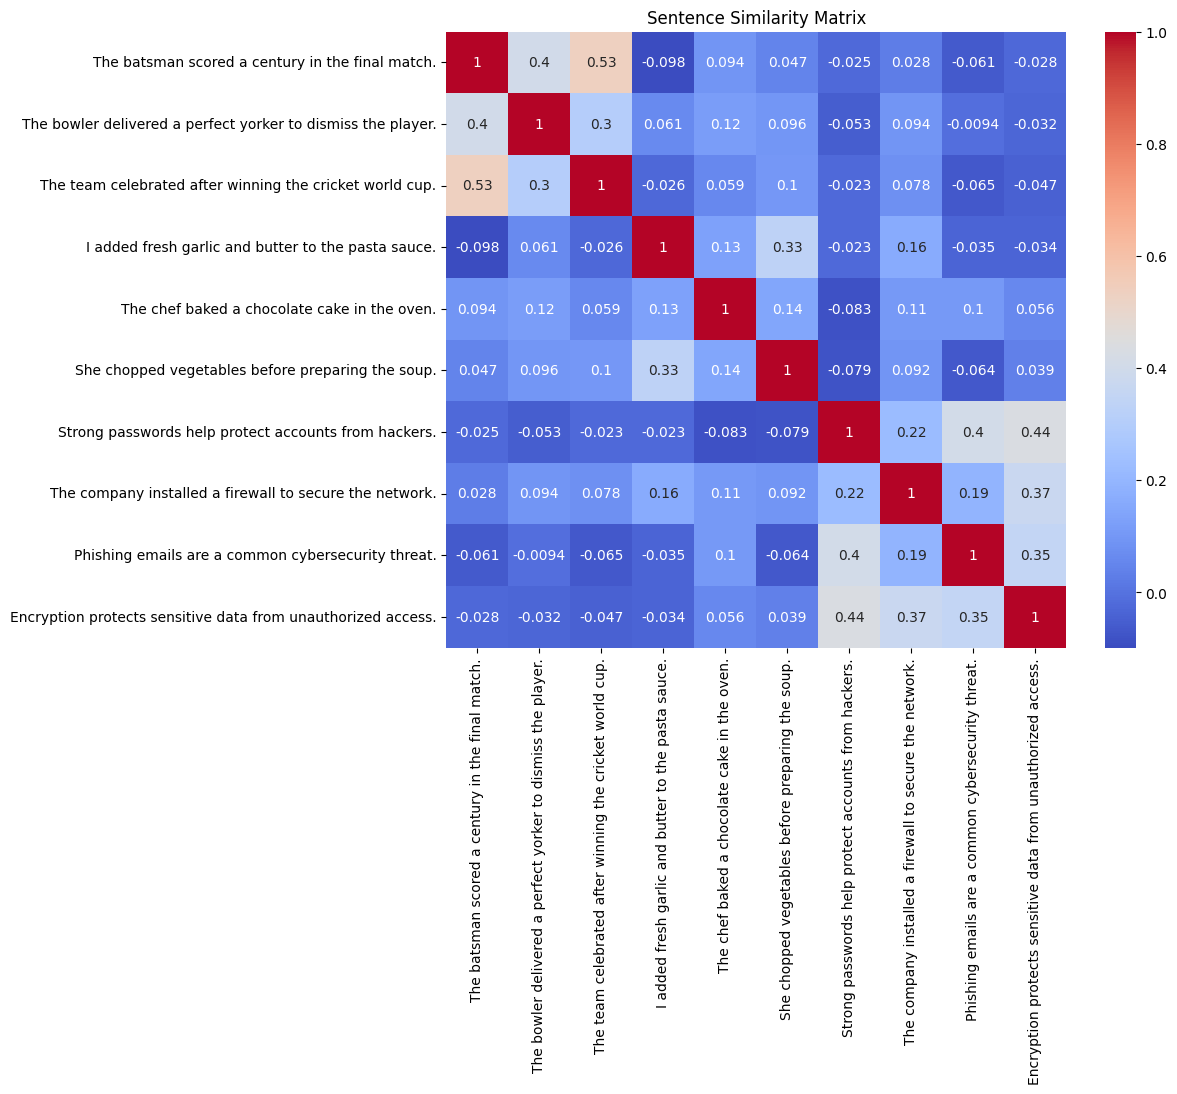

In [14]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

plt.figure(figsize=(10,8))
sns.heatmap(df, cmap="coolwarm", annot=True)
plt.title("Sentence Similarity Matrix")
plt.show()

In [18]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

The batsman scored a century in the final match.
Similarity Score: 0.5679121

The bowler delivered a perfect yorker to dismiss the player.
Similarity Score: 0.5264938

